In [ ]:
%pip install pandas

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">판다스 정리</span>

![ChatGPT Image 2026년 4월 22일 오전 10_11_47.png](<attachment:ChatGPT Image 2026년 4월 22일 오전 10_11_47.png>)
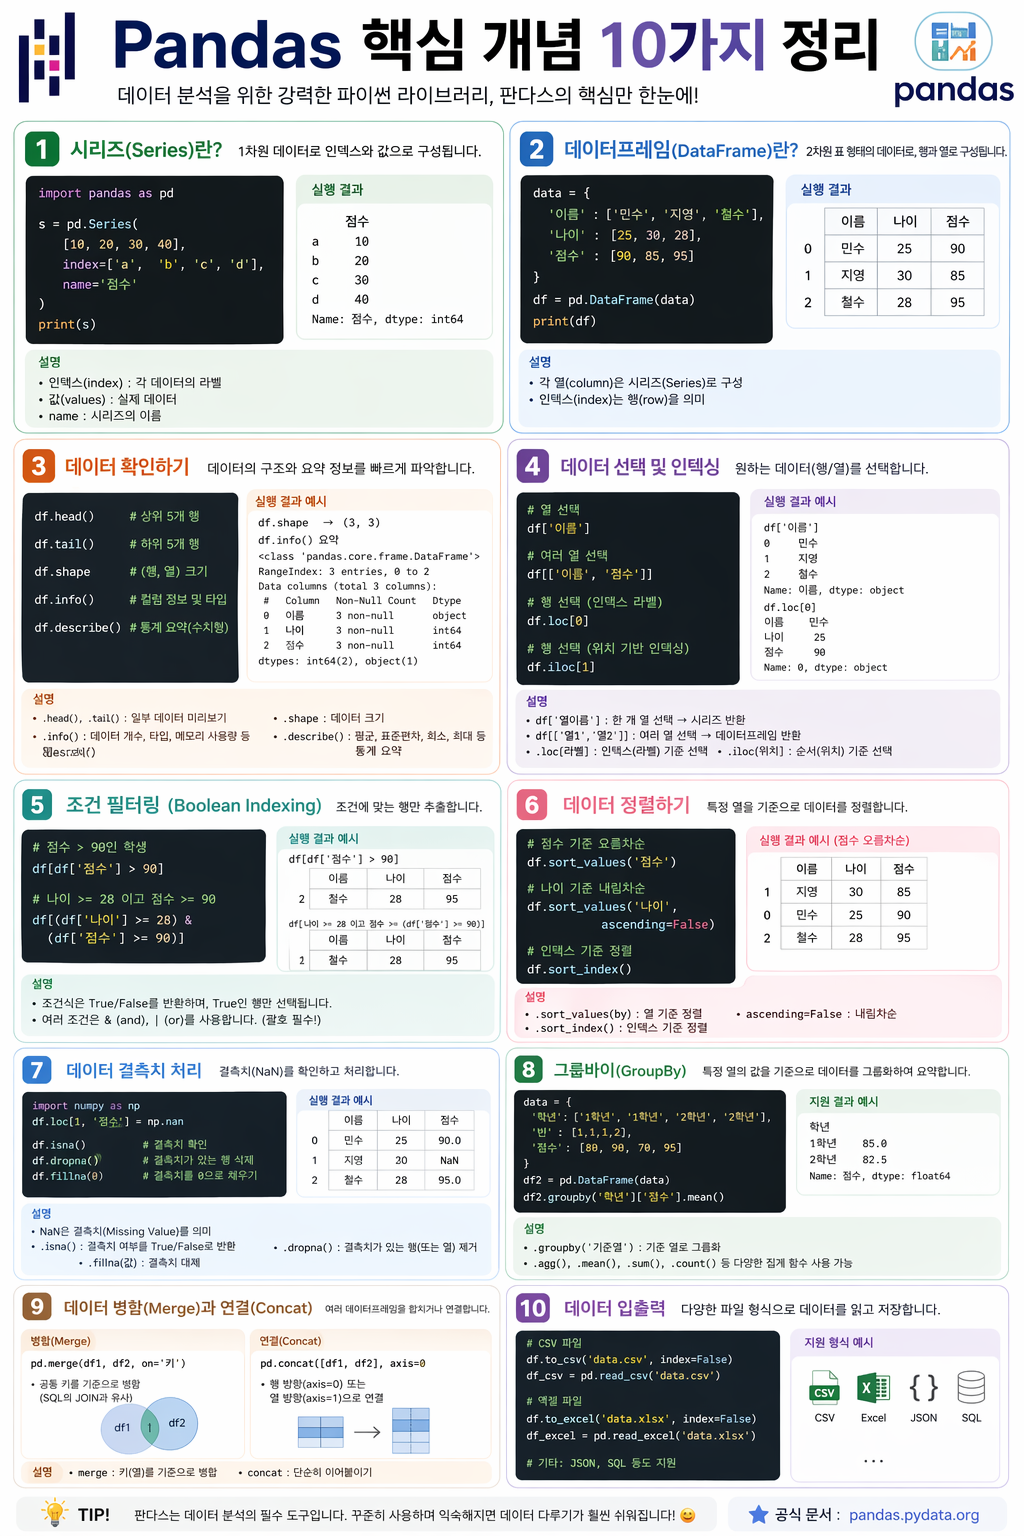

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">시리즈(series)</span>

In [2]:
import pandas as pd

s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print(s)
print("값:", s.values)
print("인덱스:", s.index)

a    10
b    20
c    30
dtype: int64
값: [10 20 30]
인덱스: Index(['a', 'b', 'c'], dtype='str')


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">데이터프레임(DataFrame)</span>

In [3]:
data = {
    '이름': ['민수', '지영', '철수'],
    '나이': [25, 30, 28]
}

df = pd.DataFrame(data)
print(df)

   이름  나이
0  민수  25
1  지영  30
2  철수  28


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">데이터 확인하기</span>

In [4]:
print(df.head())     # 위 5개
print(df.shape)      # (행, 열)
print(df.info())     # 구조 정보
print(df.describe()) # 통계 요약

   이름  나이
0  민수  25
1  지영  30
2  철수  28
(3, 2)
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   이름      3 non-null      str  
 1   나이      3 non-null      int64
dtypes: int64(1), str(1)
memory usage: 198.0 bytes
None
              나이
count   3.000000
mean   27.666667
std     2.516611
min    25.000000
25%    26.500000
50%    28.000000
75%    29.000000
max    30.000000


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">데이터 선택 & 인덱싱</span>

In [5]:
print(df['이름'])              # 한 열
print(df[['이름', '나이']])    # 여러 열
print(df.loc[0])              # 라벨 기반
print(df.iloc[1])             # 위치 기반

0    민수
1    지영
2    철수
Name: 이름, dtype: str
   이름  나이
0  민수  25
1  지영  30
2  철수  28
이름    민수
나이    25
Name: 0, dtype: object
이름    지영
나이    30
Name: 1, dtype: object


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">조건 필터링(Boolean Indexing)</span>

In [6]:
# 나이 28 이상
filtered = df[df['나이'] >= 28]
print(filtered)

   이름  나이
1  지영  30
2  철수  28


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">데이터 정렬</span>

In [7]:
# 나이 기준 오름차순
print(df.sort_values('나이'))

# 내림차순
print(df.sort_values('나이', ascending=False))

   이름  나이
0  민수  25
2  철수  28
1  지영  30
   이름  나이
1  지영  30
2  철수  28
0  민수  25


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">결측치 처리</span>

In [8]:
import numpy as np

df.loc[1, '나이'] = np.nan  # 결측치 생성

print(df.isna())      # 결측치 확인
print(df.dropna())    # 제거
print(df.fillna(0))   # 0으로 채우기

      이름     나이
0  False  False
1  False   True
2  False  False
   이름    나이
0  민수  25.0
2  철수  28.0
   이름    나이
0  민수  25.0
1  지영   0.0
2  철수  28.0


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">GroupBy</span>

In [9]:
data = {
    '학년': ['1학년', '1학년', '2학년'],
    '점수': [80, 90, 70]
}
df2 = pd.DataFrame(data)

result = df2.groupby('학년')['점수'].mean()
print(result)

학년
1학년    85.0
2학년    70.0
Name: 점수, dtype: float64


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">데이터 병합 & 연결</span>

In [10]:
df1 = pd.DataFrame({'이름': ['민수', '지영'], '점수': [90, 85]})
df2 = pd.DataFrame({'이름': ['민수', '지영'], '나이': [25, 30]})

# 병합 (merge)
merged = pd.merge(df1, df2, on='이름')
print(merged)

# 연결 (concat)
concat = pd.concat([df1, df1])
print(concat)

   이름  점수  나이
0  민수  90  25
1  지영  85  30
   이름  점수
0  민수  90
1  지영  85
0  민수  90
1  지영  85


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">파일 입출력</span>

In [11]:
# 저장
df.to_csv('test.csv', index=False)

# 불러오기
loaded = pd.read_csv('test.csv')
print(loaded)

   이름    나이
0  민수  25.0
1  지영   NaN
2  철수  28.0


Series → 1차원  
DataFrame → 표  
loc / iloc → 선택 핵심  
Boolean → 필터링 핵심  
groupby → 분석 핵심  